In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Global status color mapping
STATUS_COLORS = {
    'functional': 'green',
    'functional needs repair': 'orange',
    'non functional': 'red'
}

# Helper function to apply consistent colors
def apply_status_colors(ax):
    labels = [text.get_text() for text in ax.get_legend().get_texts()]
    colors = [STATUS_COLORS.get(label, 'gray') for label in labels]

    # Fix legend colors
    for patch, color in zip(ax.get_legend().legend_handles, colors):
        patch.set_color(color)

    # Fix bar colors
    for bar_container, color in zip(ax.containers, colors):
        for bar in bar_container:
            bar.set_color(color)

In [3]:
df= pd.read_csv("../data/cleaned_data.csv")
df.head()

,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,num_private,basin,region,...,source,source_type,source_class,waterpoint_type,waterpoint_type_group,status_group,year_recorded,installer_grouped,funder_grouped,lga_grouped
0,6000.0,2011-03-14,Roman,1390.000000,Roman,34.938093,-9.856322,37.204756,Lake Nyasa,Iringa,...,spring,spring,groundwater,communal standpipe,communal standpipe,functional,2011,Other,Other,Ludewa
1,0.0,2013-03-06,Grumeti,1399.000000,GRUMETI,34.698766,-2.147466,37.204756,Lake Victoria,Mara,...,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional,2013,Other,Other,Serengeti
2,25.0,2013-02-25,Lottery Club,686.000000,World vision,37.460664,-3.821329,37.204756,Pangani,Manyara,...,dam,dam,surface,communal standpipe multiple,communal standpipe,functional,2013,Other,Other,Simanjiro
3,0.0,2013-01-28,Unicef,263.000000,UNICEF,38.486161,-11.155298,37.204756,Ruvuma / Southern Coast,Mtwara,...,machine dbh,borehole,groundwater,communal standpipe multiple,communal standpipe,non functional,2013,Other,Unicef,Nanyumbu
4,0.0,2011-07-13,Action In A,1018.860839,Artisan,31.130847,-1.825359,37.204756,Lake Victoria,Kagera,...,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional,2011,Other,Other,Karagwe


In [4]:
df.head()

,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,num_private,basin,region,...,source,source_type,source_class,waterpoint_type,waterpoint_type_group,status_group,year_recorded,installer_grouped,funder_grouped,lga_grouped
0,6000.0,2011-03-14,Roman,1390.000000,Roman,34.938093,-9.856322,37.204756,Lake Nyasa,Iringa,...,spring,spring,groundwater,communal standpipe,communal standpipe,functional,2011,Other,Other,Ludewa
1,0.0,2013-03-06,Grumeti,1399.000000,GRUMETI,34.698766,-2.147466,37.204756,Lake Victoria,Mara,...,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional,2013,Other,Other,Serengeti
2,25.0,2013-02-25,Lottery Club,686.000000,World vision,37.460664,-3.821329,37.204756,Pangani,Manyara,...,dam,dam,surface,communal standpipe multiple,communal standpipe,functional,2013,Other,Other,Simanjiro
3,0.0,2013-01-28,Unicef,263.000000,UNICEF,38.486161,-11.155298,37.204756,Ruvuma / Southern Coast,Mtwara,...,machine dbh,borehole,groundwater,communal standpipe multiple,communal standpipe,non functional,2013,Other,Unicef,Nanyumbu
4,0.0,2011-07-13,Action In A,1018.860839,Artisan,31.130847,-1.825359,37.204756,Lake Victoria,Kagera,...,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional,2011,Other,Other,Karagwe


In [5]:
df.columns

Index(['amount_tsh', 'date_recorded', 'funder', 'gps_height', 'installer',
       'longitude', 'latitude', 'num_private', 'basin', 'region', 'lga',
       'population', 'public_meeting', 'scheme_management', 'permit',
       'construction_year', 'extraction_type', 'extraction_type_group',
       'extraction_type_class', 'management', 'management_group', 'payment',
       'payment_type', 'water_quality', 'quality_group', 'quantity',
       'quantity_group', 'source', 'source_type', 'source_class',
       'waterpoint_type', 'waterpoint_type_group', 'status_group',
       'year_recorded', 'installer_grouped', 'funder_grouped', 'lga_grouped'],
      dtype='str')

In [6]:
df.describe()


,amount_tsh,gps_height,longitude,latitude,num_private,population,construction_year,year_recorded
count,59400.000000,59400.000000,59400.000000,5.940000e+04,59400.000000,59400.000000,59400.000000,59400.000000
mean,317.650385,1018.860839,35.149669,-5.706033e+00,37.204756,281.087167,1996.814686,2011.921667
std,2997.574558,496.110517,2.567349,2.946019e+00,11.502588,451.765813,10.065781,0.958758
min,0.000000,-90.000000,29.607122,-1.164944e+01,1.000000,1.000000,1960.000000,2002.000000
25%,0.000000,903.000000,33.354079,-8.540621e+00,37.204756,100.000000,1996.000000,2011.000000
50%,0.000000,1018.860839,35.149669,-5.021597e+00,37.204756,281.087167,1996.814686,2012.000000
75%,20.000000,1319.250000,37.178387,-3.326156e+00,37.204756,281.087167,2004.000000,2013.000000
max,350000.000000,2770.000000,40.345193,-2.000000e-08,1776.000000,30500.000000,2013.000000,2013.000000


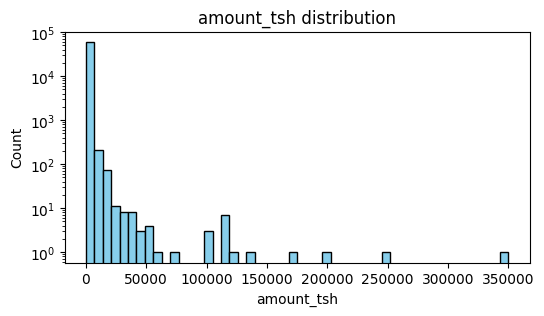

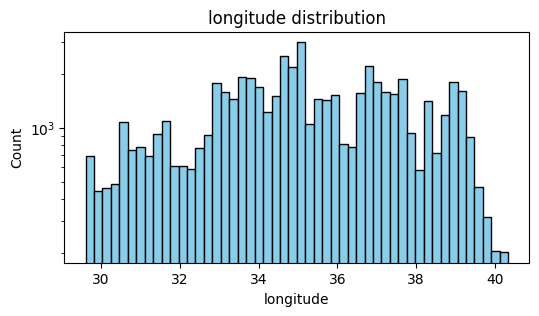

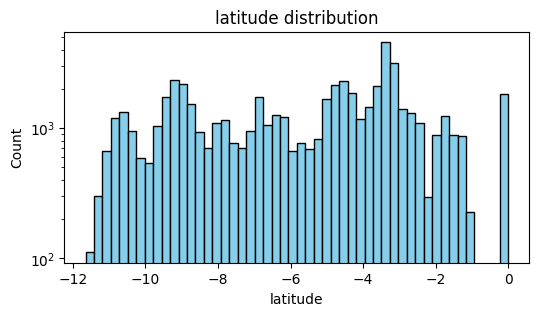

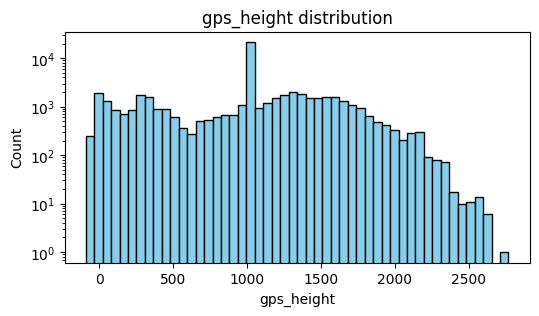

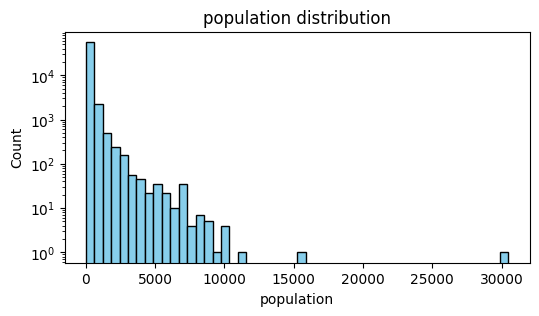

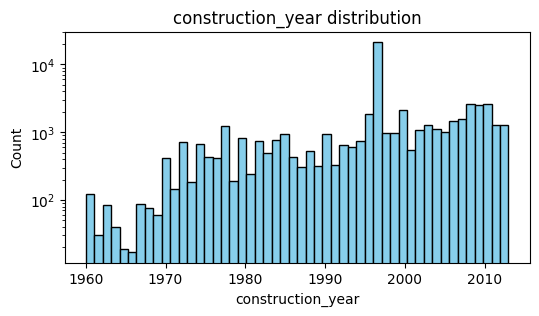

In [7]:

numeric_cols = ['amount_tsh', 'longitude', 'latitude','gps_height', 'population', 'construction_year']

for col in numeric_cols:
    plt.figure(figsize=(6,3))
    plt.hist(df[col], bins=50, color='skyblue', edgecolor='black')
    plt.title(f'{col} distribution')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.yscale('log')  # for skewed distributions
    plt.show()

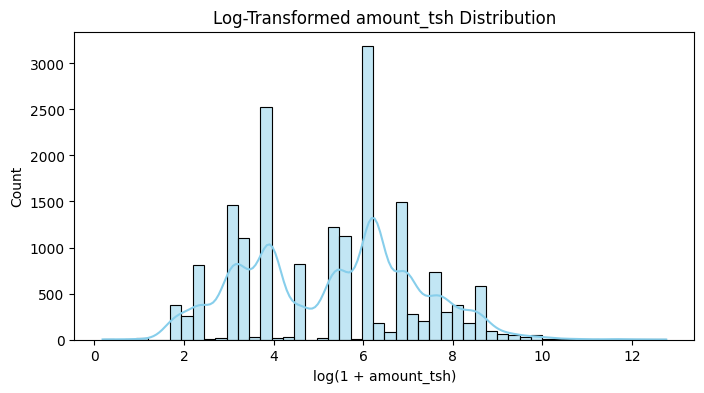

In [8]:

# Copy the data so we don't overwrite original
amount = df['amount_tsh'].copy()

# Replace zeros with NaN or a small number to avoid log(0)
amount_nonzero = amount.replace(0, np.nan)

# Plot histogram with log scale
plt.figure(figsize=(8,4))
sns.histplot(np.log1p(amount_nonzero), bins=50, color='skyblue', kde=True)  # log1p = log(1+x)
plt.title("Log-Transformed amount_tsh Distribution")
plt.xlabel("log(1 + amount_tsh)")
plt.ylabel("Count")
plt.show()

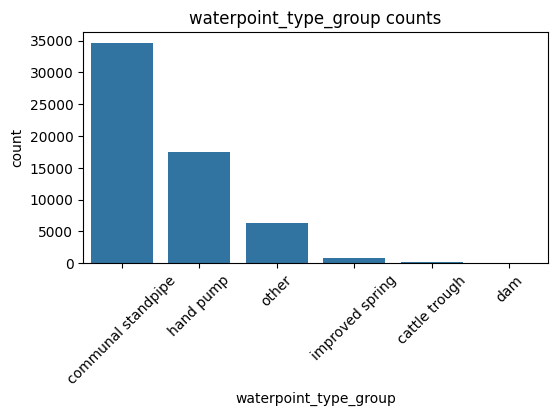

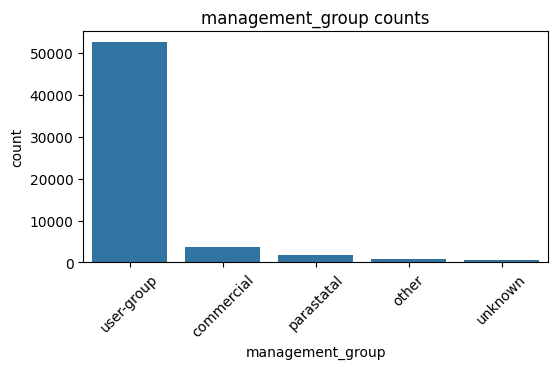

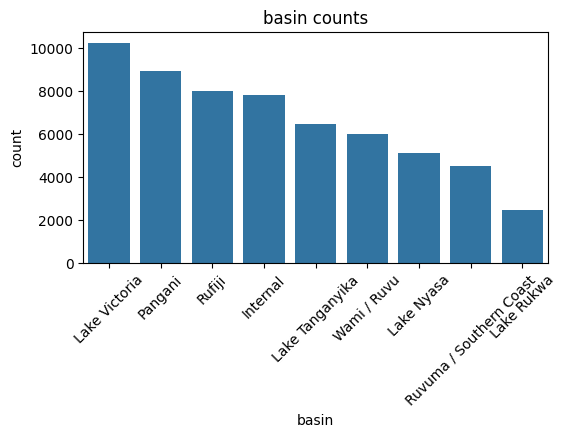

In [9]:

categorical_cols = ['waterpoint_type_group', 'management_group', 'basin']

for col in categorical_cols:
    plt.figure(figsize=(6,3))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f'{col} counts')
    plt.xticks(rotation=45)
    plt.show()

## 1. Do older pumps fail more often than newer ones?

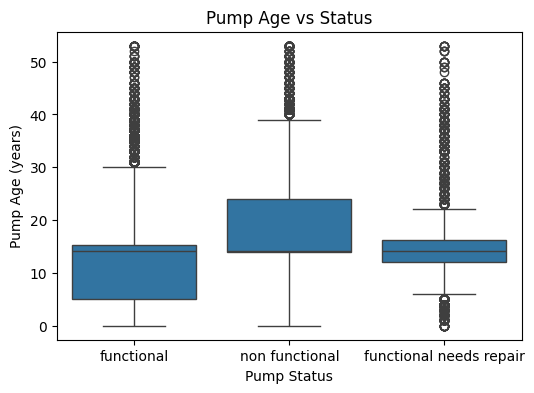

In [10]:
pump_age = df['year_recorded'] - df['construction_year']

valid = (df['construction_year'] > 0) & (pump_age >= 0)
pump_age = pump_age[valid]
status = df.loc[valid, 'status_group']

plt.figure(figsize=(6,4))
sns.boxplot(x=status, y=pump_age)
plt.title("Pump Age vs Status")
plt.xlabel("Pump Status")
plt.ylabel("Pump Age (years)")
plt.show()

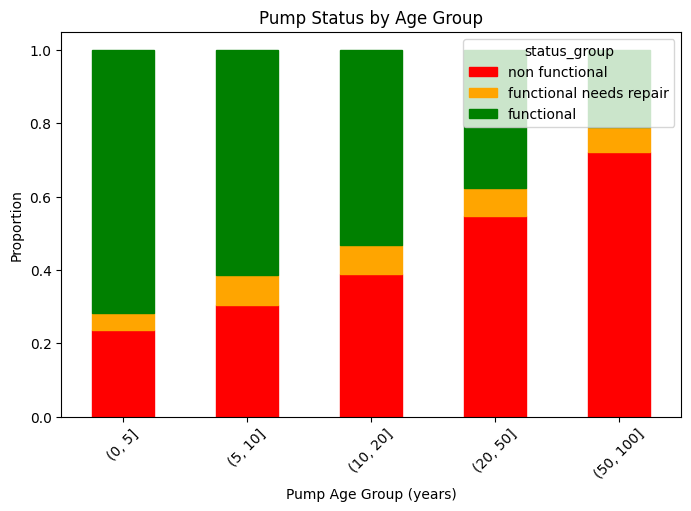

In [11]:
# Create temporary age bins
age_bins = pd.cut(pump_age, bins=[0,5,10,20,50,100])

# Crosstab (proportions)
age_status = pd.crosstab(age_bins, status, normalize='index')

# Plot
ax =age_status[['non functional','functional needs repair','functional']].plot(
    kind='bar', stacked=True, figsize=(8,5)
)
apply_status_colors(ax)


plt.title("Pump Status by Age Group")
plt.xlabel("Pump Age Group (years)")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.show()

### Insights:
There is a clear trend:
The older the pump, the higher the likelihood it has failed.
This suggests age is a strong factor in pump reliability.

## 2. Are pumps serving larger populations more likely to be non-functional?

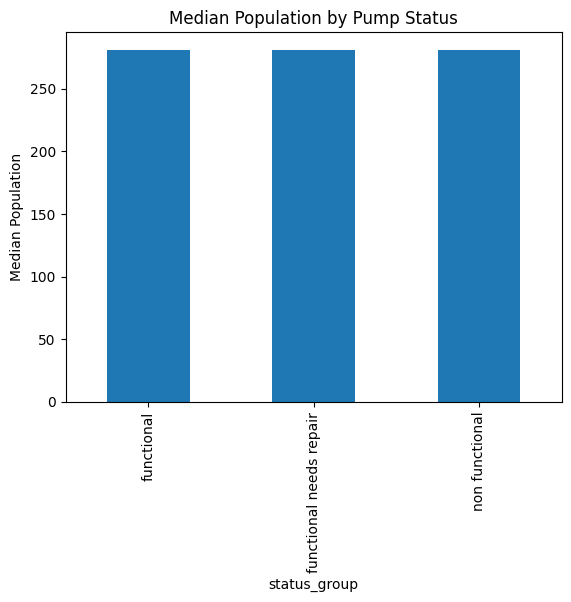

In [12]:
df.groupby('status_group')['population'].median().plot(kind='bar')
plt.title("Median Population by Pump Status")
plt.ylabel("Median Population")
plt.show()

### Insights:
There is no clear trend:
population does not show a strong factor in pump reliability.

## 3. Are certain regions or basins more prone to pump failures?

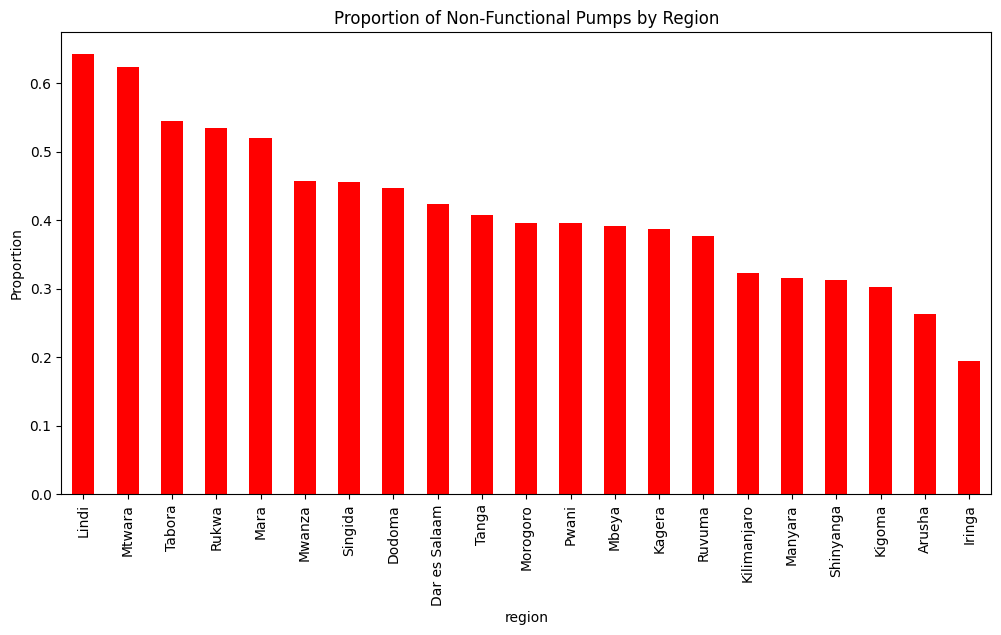

In [13]:
# Crosstab for region
region_status = pd.crosstab(df['region'], df['status_group'])
region_status_norm = region_status.div(region_status.sum(axis=1), axis=0)

non_func_rate = region_status['non functional'] / region_status.sum(axis=1)
non_func_rate.sort_values(ascending=False).plot(kind='bar', figsize=(12,6), color='red')
plt.title("Proportion of Non-Functional Pumps by Region")
plt.ylabel("Proportion")
plt.show()

### Insights:
There is a clear trend:
Some regions have high failure rate, higher than other regions.

## 4. How does the installer relate to long-term functionality?

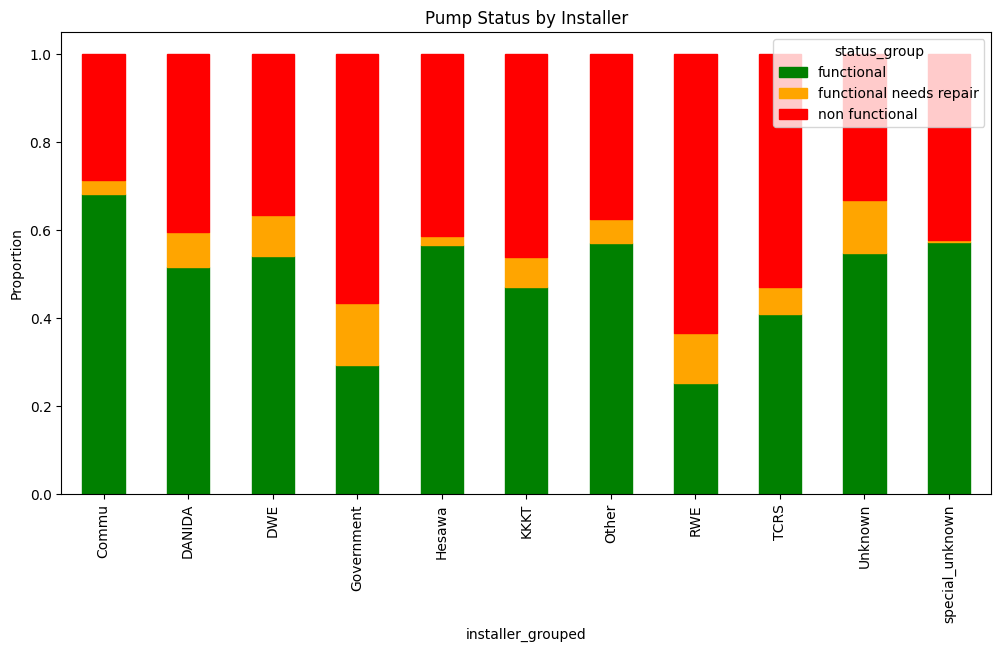

In [14]:
installer_status = pd.crosstab(df['installer_grouped'], df['status_group'])
installer_status_norm = installer_status.div(installer_status.sum(axis=1), axis=0)

ax = installer_status_norm.plot(kind='bar', stacked=True, figsize=(12,6))
apply_status_colors(ax)

plt.title("Pump Status by Installer")
plt.ylabel("Proportion")
plt.show()

### Insights:
There is a small trend:
Government installed pumps seem to be more likely to fail. This suggests installer is a factor in pump reliability.

## 5. Which pump types have the highest proportion of functional pumps?

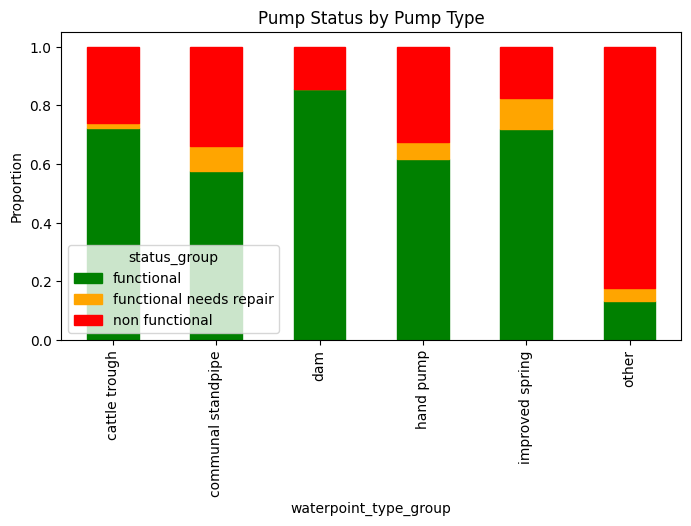

In [15]:
pump_type_status = pd.crosstab(df['waterpoint_type_group'], df['status_group'])
pump_type_status_norm = pump_type_status.div(pump_type_status.sum(axis=1), axis=0)

ax = pump_type_status_norm.plot(kind='bar', stacked=True, figsize=(8,4))

apply_status_colors(ax)

plt.title("Pump Status by Pump Type")
plt.ylabel("Proportion")
plt.show()

### Insights:
There is a slight trend:
“Other” and “communal standpipe” pump types are the most unreliable, with the highest proportion of non working pumps.


## 6. Does water quality or quantity influence pump status?

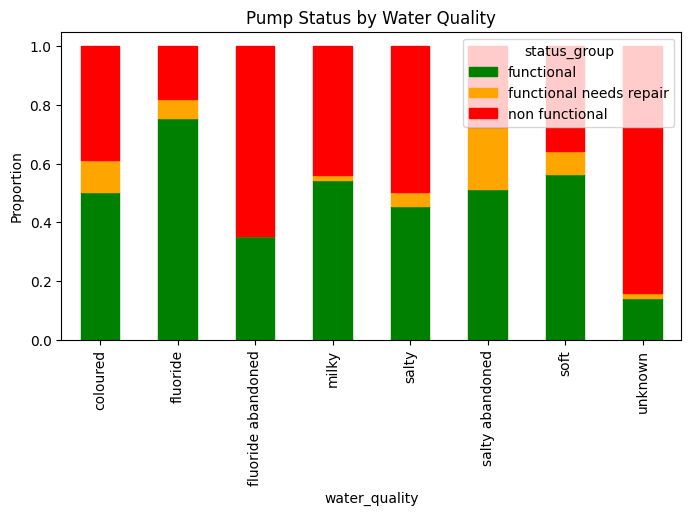

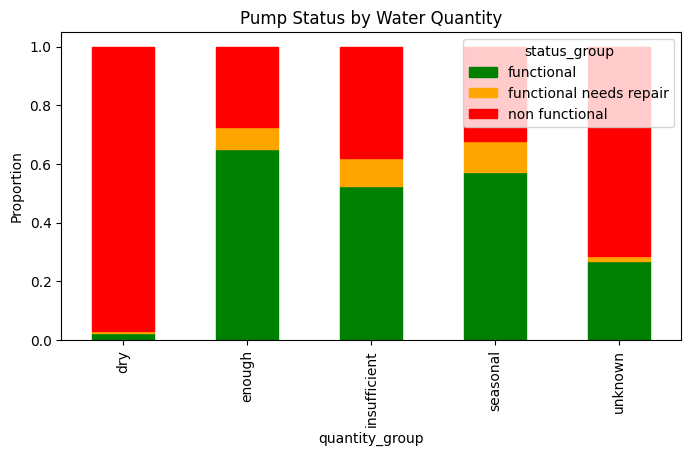

In [16]:
quality_status = pd.crosstab(df['water_quality'], df['status_group'])
quality_status_norm = quality_status.div(quality_status.sum(axis=1), axis=0)
ax = quality_status_norm.plot(kind='bar', stacked=True, figsize=(8,4))
apply_status_colors(ax)

plt.title("Pump Status by Water Quality")
plt.ylabel("Proportion")
plt.show()

quantity_status = pd.crosstab(df['quantity_group'], df['status_group'])
quantity_status_norm = quantity_status.div(quantity_status.sum(axis=1), axis=0)
ax = quantity_status_norm.plot(kind='bar', stacked=True, figsize=(8,4))
apply_status_colors(ax)

plt.title("Pump Status by Water Quantity")
plt.ylabel("Proportion")
plt.show()

### Insights:
There is a clear trend:
the pumps at the areas. with less water are more prone to failure due to obvious reasons.


## 7. How does the pump manager relate to long-term functionality?

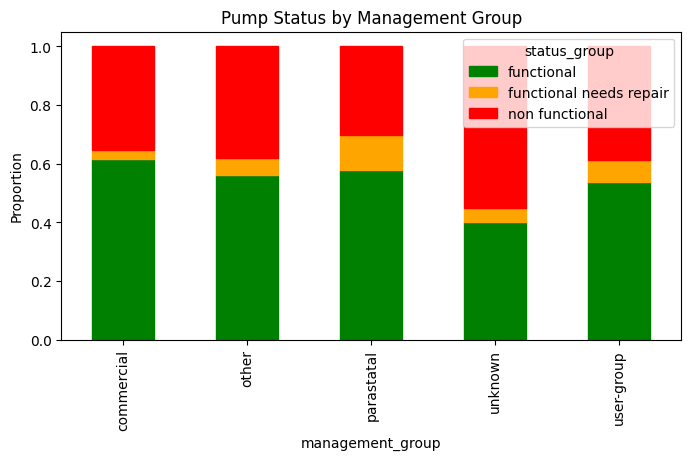

In [17]:
management_status = pd.crosstab(df['management_group'], df['status_group'])
management_status_norm = management_status.div(management_status.sum(axis=1), axis=0)

ax = management_status_norm.plot(kind='bar', stacked=True, figsize=(8,4))
apply_status_colors(ax)

plt.title("Pump Status by Management Group")
plt.ylabel("Proportion")
plt.show()

### Insights:
There is no clear trend:



## Outlier Investigation

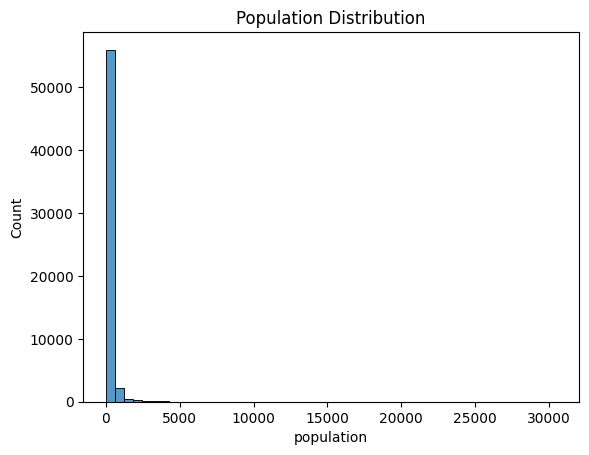

In [18]:
sns.histplot(df['population'], bins=50)
plt.title("Population Distribution")
plt.show()

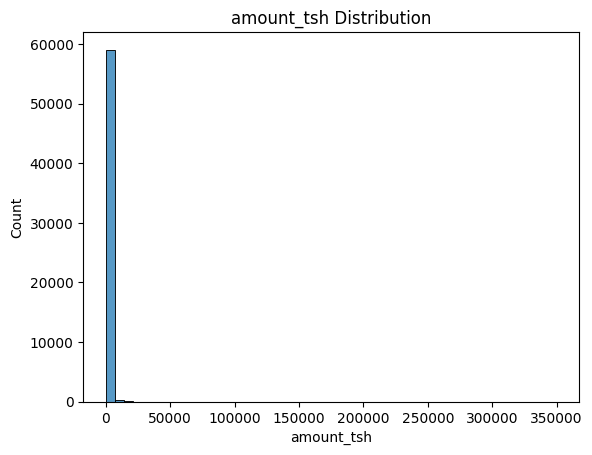

In [19]:
sns.histplot(df['amount_tsh'], bins=50)
plt.title("amount_tsh Distribution")
plt.show()

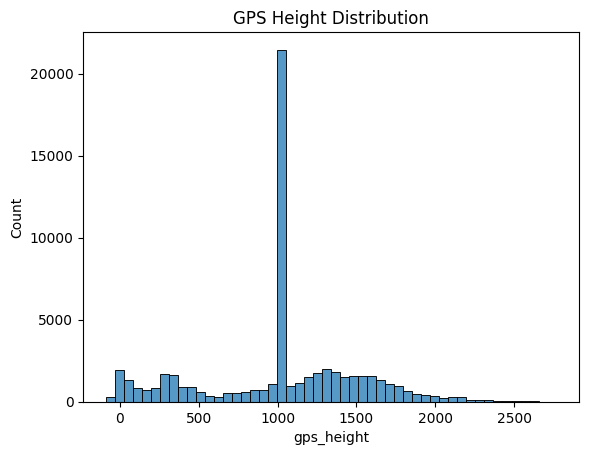

In [20]:
sns.histplot(df['gps_height'], bins=50)
plt.title("GPS Height Distribution")
plt.show()

In [21]:
numeric_cols = df.select_dtypes(include=np.number)

outliers = {}

for col in numeric_cols.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers[col] = df[(df[col] < lower) | (df[col] > upper)]

# columns that have outliers
for col, data in outliers.items():
    print(f"{col}: {len(data)} outliers")

amount_tsh: 11161 outliers
gps_height: 8231 outliers
longitude: 0 outliers
latitude: 0 outliers
num_private: 757 outliers
population: 4142 outliers
construction_year: 7225 outliers
year_recorded: 31 outliers


clearly outlier exists.

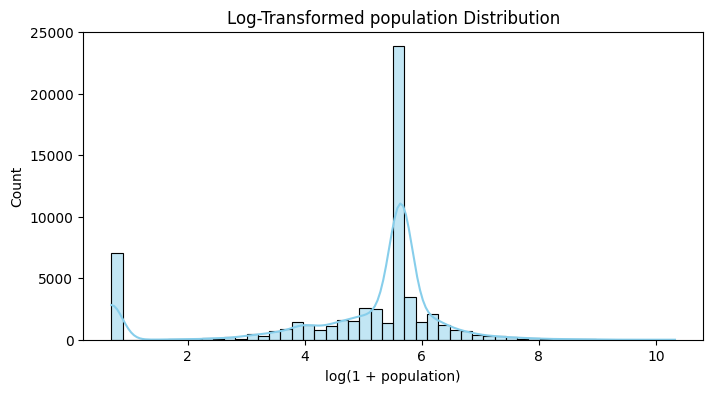

In [22]:


# Copy the data
population = df['population'].copy()

# Replace zeros with NaN or a small number to avoid log(0)
population_nonzero = population.replace(0, np.nan)

# Plot histogram with log scale
plt.figure(figsize=(8,4))
sns.histplot(np.log1p(population_nonzero), bins=50, color='skyblue', kde=True)  # log1p = log(1+x)
plt.title("Log-Transformed population Distribution")
plt.xlabel("log(1 + population)")
plt.ylabel("Count")
plt.show()

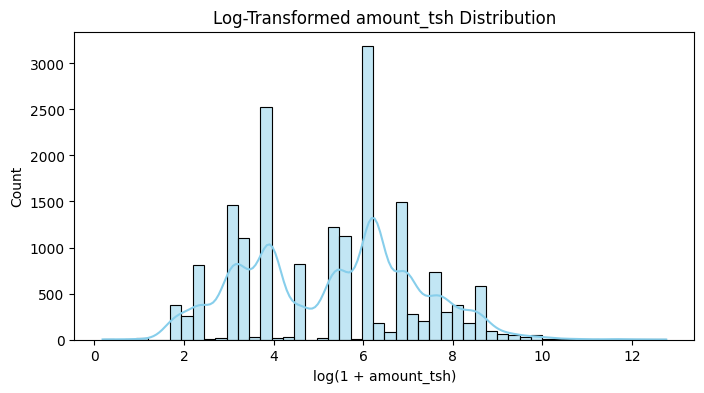

In [23]:


# Copy the data
amount = df['amount_tsh'].copy()

# Replace zeros with NaN or a small number to avoid log(0)
amount_nonzero = amount.replace(0, np.nan)

# Plot histogram with log scale
plt.figure(figsize=(8,4))
sns.histplot(np.log1p(amount_nonzero), bins=50, color='skyblue', kde=True)  # log1p = log(1+x)
plt.title("Log-Transformed amount_tsh Distribution")
plt.xlabel("log(1 + amount_tsh)")
plt.ylabel("Count")
plt.show()